<div style="padding:24px;border-left:8px solid #C99700;background:#071B33;color:white;border-radius:8px">
<h1 style="margin:0">Lab 04 · Regime Risk and Backtest Integrity</h1>
<p style="font-size:17px;margin-bottom:0">A cross-asset risk study where timing conventions are part of the mathematics.</p>
</div>

**Research question.** How do cross-asset dependence and tail losses change in observable stress regimes, and which volatility-targeting conclusions survive lag, turnover, and VaR-coverage audits?

**Evidence.** Versioned adjusted-price and VIX outputs from the regime-risk project. SPY, TLT, and GLD are investable proxies; VIX is a signal only.

## 1. Timing is a filtration constraint

A valid weight $w_t$ must be measurable with respect to information available before the return $r_t$ is realized. For volatility targeting,

$$w_t=\min\!\left(w_{max},\frac{\sigma^*}{\widehat\sigma_{t|t-1}}\right),\qquad r^{strat}_t=w_t r_t-c|w_t-w_{t-1}|.$$

Using a rolling standard deviation that includes $r_t$ to size the exposure applied to $r_t$ violates this constraint. A one-line missing lag can turn future information into apparent skill.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_root():
    here=Path.cwd().resolve()
    for candidate in (here,*here.parents):
        if (candidate/'projects'/'regime_risk'/'output'/'simple_returns.csv').exists():
            return candidate
    raise FileNotFoundError('Run projects/regime_risk/run_research.py first')

ROOT=find_root(); OUT=ROOT/'projects'/'regime_risk'/'output'
sys.path.insert(0,str(ROOT))
from utils.quant_models import performance_summary, historical_var_cvar, kupiec_unconditional_coverage

returns=pd.read_csv(OUT/'simple_returns.csv',index_col='Date',parse_dates=True)
regimes=pd.read_csv(OUT/'observable_regimes.csv',index_col='Date',parse_dates=True)
saved_target=pd.read_csv(OUT/'spy_volatility_target.csv',index_col='Date',parse_dates=True)
assets=['SPY','TLT','GLD']
plt.style.use('seaborn-v0_8-whitegrid')
NAVY, BLUE, GOLD, RED, GREEN='#071B33','#1676B8','#C99700','#C84C4C','#26866A'
pd.options.display.float_format='{:,.4f}'.format
print((OUT/'provenance.txt').read_text())
display(pd.DataFrame({a:performance_summary(returns[a]) for a in assets}).T)

Source: Yahoo Finance adjusted close via yfinance
Requested tickers: SPY, TLT, GLD, ^VIX
Requested start: 2010-01-01
Rows: 4189
First observation: 2010-01-04 00:00:00
Last observation: 2026-08-27 00:00:00
Generated UTC: 2026-08-28T00:53:36.658719+00:00
SPY, TLT, and GLD are investable proxies; ^VIX is a signal only.
Regime uses lagged VIX; every strategy volatility input is lagged.
Synthetic fallback is for software validation, not market conclusions.



,observations,annualized_geometric_return,annualized_volatility,sharpe_ratio,max_drawdown,period_VaR_95_loss,period_ES_95_loss,period_VaR_99_loss,period_ES_99_loss,skewness,excess_kurtosis
SPY,"4,188.0000",0.1422,0.1708,0.8329,-0.3372,0.0164,0.0260,0.0303,0.0438,-0.3304,12.0374
TLT,"4,188.0000",0.0249,0.1492,0.1666,-0.4835,0.0149,0.0202,0.0226,0.0300,0.0486,3.5788
GLD,"4,188.0000",0.0845,0.1673,0.5051,-0.4556,0.0166,0.0249,0.0295,0.0410,-0.5405,6.0801


## 2. Observable stress, not hindsight labels

Stress is defined when yesterday's VIX exceeds its trailing one-year 75th percentile, also computed using lagged observations. This adaptive definition avoids full-sample thresholds and allows the regime to be known before the trading day begins.

days  annualized_mean  annualized_vol  VaR_99_loss  ES_99_loss  \
regime asset                                                                   
Calm   SPY    3162           0.1326          0.1239       0.0224      0.0283   
       TLT    3162           0.0294          0.1361       0.0214      0.0243   
       GLD    3162           0.0859          0.1581       0.0260      0.0393   
Stress SPY     900           0.2430          0.2758       0.0450      0.0669   
       TLT     900           0.0209          0.1890       0.0302      0.0448   
       GLD     900           0.1221          0.1943       0.0339      0.0417   

              correlation_with_SPY  
regime asset                        
Calm   SPY                  1.0000  
       TLT                 -0.1897  
       GLD                  0.1172  
Stress SPY                  1.0000  
       TLT                 -0.3816  
       GLD                  0.0097

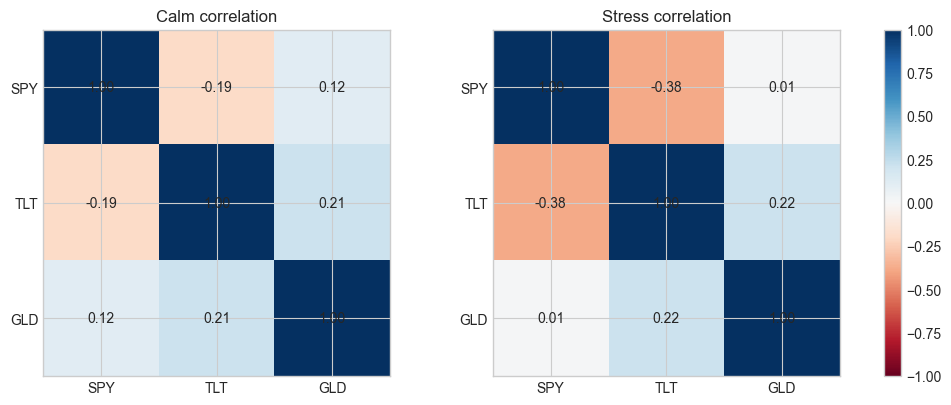

In [2]:
panel=returns.join(regimes[['lagged_vix','trailing_vix_75pct','stress_regime']]).dropna()
rows=[]
for state,group in panel.groupby('stress_regime'):
    label='Stress' if int(state)==1 else 'Calm'
    for asset in assets:
        var,es=historical_var_cvar(group[asset],confidence=.99)
        rows.append({'regime':label,'asset':asset,'days':len(group),
                     'annualized_mean':252*group[asset].mean(),
                     'annualized_vol':np.sqrt(252)*group[asset].std(),
                     'VaR_99_loss':var,'ES_99_loss':es,
                     'correlation_with_SPY':group[asset].corr(group.SPY)})
conditional=pd.DataFrame(rows).set_index(['regime','asset'])
display(conditional)

fig,axes=plt.subplots(1,2,figsize=(11.5,4.5))
for ax,(state,title) in zip(axes,[(0,'Calm'),(1,'Stress')]):
    matrix=panel.loc[panel.stress_regime==state,assets].corr()
    im=ax.imshow(matrix,cmap='RdBu',vmin=-1,vmax=1)
    ax.set_xticks(range(3),assets); ax.set_yticks(range(3),assets); ax.set_title(f'{title} correlation')
    for i in range(3):
        for j in range(3): ax.text(j,i,f'{matrix.iloc[i,j]:.2f}',ha='center',va='center')
fig.colorbar(im,ax=axes.ravel().tolist(),fraction=.025); plt.show()

## 3. A controlled leakage experiment

Three apparently similar forecasts expose the timing issue:

1. **Valid:** volatility through $t-1$ sizes the position for $t$.
2. **Contemporaneous:** volatility through $t$ sizes the position for $t$.
3. **Future-contaminated:** volatility through $t+1$ sizes the position for $t$.

Only the first is implementable. All charge two basis points on absolute exposure changes.

,observations,annualized_geometric_return,annualized_volatility,sharpe_ratio,max_drawdown,period_VaR_95_loss,period_ES_95_loss,period_VaR_99_loss,period_ES_99_loss,skewness,excess_kurtosis,average_turnover
Valid lagged,"4,188.0000",0.0986,0.1107,0.8911,-0.1438,0.0114,0.0173,0.0209,0.0276,-0.7742,3.6125,0.0299
Contemporaneous leak,"4,188.0000",0.1256,0.1009,1.2449,-0.1205,0.0109,0.0145,0.0171,0.0199,-0.3742,0.7030,0.0300
Future leak,"4,188.0000",0.1353,0.1001,1.3525,-0.1295,0.0106,0.0142,0.0164,0.0191,-0.3303,0.5688,0.0302


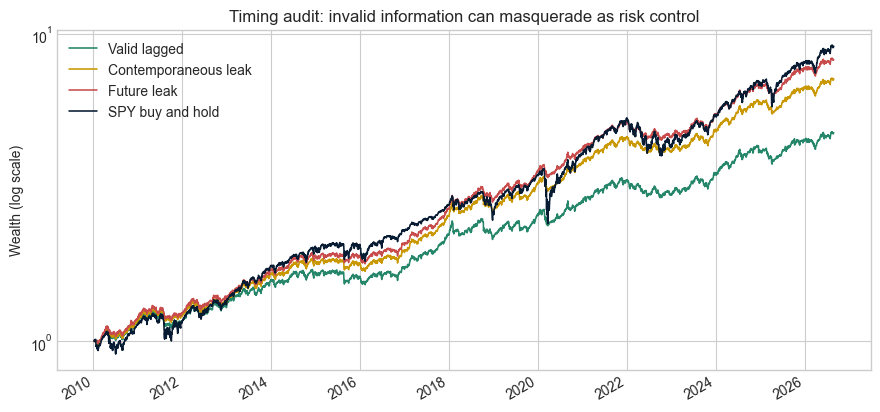

Maximum difference between saved project exposure and reconstructed valid exposure: 1.084e-13


In [3]:
spy=returns.SPY
realized=spy.rolling(21).std(ddof=1)*np.sqrt(252)

def target_from_forecast(forecast,cost_bps=2):
    exposure=(.10/forecast).clip(0,1.5).fillna(0)
    turnover=exposure.diff().abs().fillna(exposure.abs())
    return pd.DataFrame({'forecast':forecast,'exposure':exposure,'turnover':turnover,
                         'net':exposure*spy-turnover*cost_bps*1e-4})

timing={
    'Valid lagged':target_from_forecast(realized.shift(1)),
    'Contemporaneous leak':target_from_forecast(realized),
    'Future leak':target_from_forecast(realized.shift(-1)),
}
timing_summary=pd.DataFrame({name:performance_summary(frame.net) for name,frame in timing.items()}).T
timing_summary['average_turnover']=[frame.turnover.mean() for frame in timing.values()]
display(timing_summary)

wealth=pd.DataFrame({name:(1+frame.net).cumprod() for name,frame in timing.items()})
wealth['SPY buy and hold']=(1+spy).cumprod()
ax=wealth.plot(figsize=(10.5,5),logy=True,color=[GREEN,GOLD,RED,NAVY],linewidth=1.15)
ax.set(title='Timing audit: invalid information can masquerade as risk control',ylabel='Wealth (log scale)',xlabel='')
plt.show()
max_difference=(saved_target.exposure-timing['Valid lagged'].exposure).abs().max()
print(f'Maximum difference between saved project exposure and reconstructed valid exposure: {max_difference:.3e}')

## 4. Tail-risk model validation

A rolling historical 99% VaR forecast is the negative trailing 1% return quantile, lagged one day. The Kupiec unconditional-coverage test compares the observed exception rate with 1%. Its likelihood-ratio statistic tests frequency—not independence, clustering, or loss severity.

,historical VaR
forecast_days,"3,936.0000"
exceptions,60.0000
observed_exception_rate,0.0152
expected_exception_rate,0.0100
Kupiec_LR,9.4209
Kupiec_p_value,0.0021


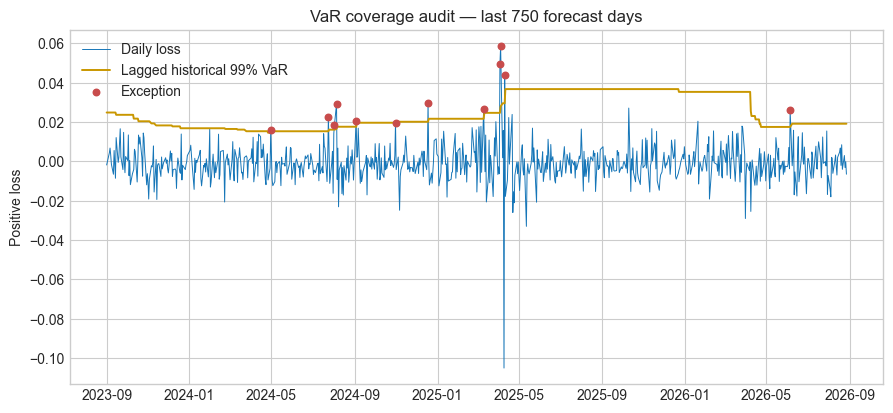

In [4]:
var99=-spy.rolling(252,min_periods=252).quantile(.01).shift(1)
aligned=pd.concat({'loss':-spy,'VaR99':var99},axis=1).dropna()
lr,pvalue,exceptions=kupiec_unconditional_coverage(aligned.loss,aligned.VaR99,.99)
coverage=pd.Series({'forecast_days':len(aligned),'exceptions':exceptions,
                    'observed_exception_rate':exceptions/len(aligned),
                    'expected_exception_rate':.01,'Kupiec_LR':lr,'Kupiec_p_value':pvalue})
display(coverage.to_frame('historical VaR'))

recent=aligned.iloc[-750:]
fig,ax=plt.subplots(figsize=(10.5,4.6))
ax.plot(recent.index,recent.loss,color=BLUE,linewidth=.7,label='Daily loss')
ax.plot(recent.index,recent.VaR99,color=GOLD,linewidth=1.4,label='Lagged historical 99% VaR')
breach=recent.loss>recent.VaR99
ax.scatter(recent.index[breach],recent.loss[breach],color=RED,s=22,label='Exception',zorder=3)
ax.set(title='VaR coverage audit — last 750 forecast days',ylabel='Positive loss',xlabel='')
ax.legend(frameon=False); plt.show()

## 5. Research conclusion and model-risk register

- Stress-conditioned volatility, tail loss, and dependence can differ materially from unconditional estimates; diversification is state dependent.
- Signals and thresholds must be lagged. The reconstruction check proves that the saved project obeys its declared timing convention.
- Volatility targeting changes both exposure and turnover. Its value cannot be judged from gross Sharpe ratio alone.
- Kupiec coverage is necessary but incomplete: correctly frequent VaR exceptions may still cluster severely.

> **Boundary of the evidence.** Regime labels are descriptive, not causal. ETF histories contain one realized market path, VIX methodology and market structure can evolve, and proportional costs omit spreads, impact, borrow, and execution delay.

### Extensions

1. Add Christoffersen conditional-coverage and duration-based exception tests.
2. Replace historical VaR with filtered historical simulation and EVT peaks over threshold.
3. Estimate a dynamic conditional-correlation model without using full-sample parameters in the backtest.
4. Study whether a VIX regime improves forecasts after controlling for lagged realized volatility.